# 01 — Baseline Model (Seasonal Naive)

**Mục tiêu:** Chạy Seasonal Naive Forecast làm baseline, đánh giá bằng RMSLE.

**Workflow:**
1. Load & split dữ liệu bằng `src.data_prep.load_and_split_data()`
2. Tạo dự đoán Seasonal Naive bằng `src.baseline.seasonal_naive_forecast()`
3. Tính RMSLE bằng `src.metrics.rmsle()`
4. Lưu kết quả vào `results/metrics/baseline_rmsle.csv`

In [1]:
import sys
import os

# Thêm thư mục gốc project vào sys.path để import src/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\Asus X515\Downloads\New folder\arima_and_sarima_comparision


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Import các module tự viết
from src.data_prep import load_and_split_data
from src.baseline import seasonal_naive_forecast
from src.metrics import rmsle

print('\u2713 Import thành công tất cả modules!')

✓ Import thành công tất cả modules!


## 1. Load & Split dữ liệu

In [3]:
# Đường dẫn tới file dữ liệu đã xử lý
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'store_1_2013_2017_clean.csv')

train, test = load_and_split_data(DATA_PATH)

print(f'Train: {len(train)} ngày  ({train["date"].min().date()} \u2192 {train["date"].max().date()})')
print(f'Test : {len(test)} ngày  ({test["date"].min().date()} \u2192 {test["date"].max().date()})')
print(f'\nTrain shape: {train.shape}')
print(f'Test shape : {test.shape}')
train.head()

Train: 1551 ngày  (2013-01-01 → 2017-03-31)
Test : 137 ngày  (2017-04-01 → 2017-08-15)

Train shape: (1551, 19)
Test shape : (137, 19)


,date,sales,is_holiday,is_outlier,year,month,day,day_of_week,day_name,week_of_year,quarter,is_weekend,is_month_start,is_month_end,day_of_year,dow_sin,dow_cos,month_sin,month_cos
0,2013-01-01,0.000000,1,0,2013,1,1,1,Tuesday,1,1,0,1,0,1,0.781831,0.623490,0.5,0.866025
1,2013-01-02,7417.148000,0,0,2013,1,2,2,Wednesday,1,1,0,0,0,2,0.974928,-0.222521,0.5,0.866025
2,2013-01-03,5873.244001,0,0,2013,1,3,3,Thursday,1,1,0,0,0,3,0.433884,-0.900969,0.5,0.866025
3,2013-01-04,5919.879001,0,0,2013,1,4,4,Friday,1,1,0,0,0,4,-0.433884,-0.900969,0.5,0.866025
4,2013-01-05,6318.785010,0,0,2013,1,5,5,Saturday,1,1,1,0,0,5,-0.974928,-0.222521,0.5,0.866025


## 2. Chạy Baseline — Seasonal Naive Forecast (m=7, avg 4 tuần)

In [4]:
# Seasonal Naive: dự đoán = trung bình sales cùng ngày trong tuần của 4 tuần gần nhất
baseline_pred = seasonal_naive_forecast(train['sales'], len(test), m=7, use_avg_weeks=4)

print(f'Số lượng dự đoán: {len(baseline_pred)}')
print(f'\nMẫu 10 dự đoán đầu tiên:')
comparison = pd.DataFrame({
    'date': test['date'].values[:10],
    'actual': test['sales'].values[:10],
    'predicted': baseline_pred[:10]
})
comparison

Số lượng dự đoán: 137

Mẫu 10 dự đoán đầu tiên:


,date,actual,predicted
0,2017-04-01,15094.336000,11862.724502
1,2017-04-02,5521.681903,5497.916975
2,2017-04-03,11166.367020,11484.362000
3,2017-04-04,11028.610000,12004.882495
4,2017-04-05,15539.170000,14034.546505
5,2017-04-06,10487.067001,10563.571250
6,2017-04-07,13014.477000,13584.353001
7,2017-04-08,12509.368000,11806.774128
8,2017-04-09,5621.146000,5583.237719
9,2017-04-10,10221.429000,11650.674500


## 3. Tính RMSLE

In [5]:
# Tính RMSLE
score = rmsle(test['sales'].values, baseline_pred)

print('=' * 50)
print(f'  Baseline: Seasonal Naive (m=7, avg_weeks=4)')
print(f'  RMSLE   : {score:.6f}')
print('=' * 50)

  Baseline: Seasonal Naive (m=7, avg_weeks=4)
  RMSLE   : 0.205990


## 4. Lưu kết quả vào `results/metrics/baseline_rmsle.csv`

In [6]:
# Tạo DataFrame kết quả
results_df = pd.DataFrame({
    'model': ['Baseline'],
    'RMSLE': [score]
})

# Lưu vào results/metrics/
output_path = os.path.join(PROJECT_ROOT, 'results', 'metrics', 'baseline_rmsle.csv')
os.makedirs(os.path.dirname(output_path), exist_ok=True)
results_df.to_csv(output_path, index=False)

print(f'\u2713 Đã lưu kết quả: {output_path}')
results_df

✓ Đã lưu kết quả: C:\Users\Asus X515\Downloads\New folder\arima_and_sarima_comparision\results\metrics\baseline_rmsle.csv


,model,RMSLE
0,Baseline,0.20599


## 5. Trực quan hóa

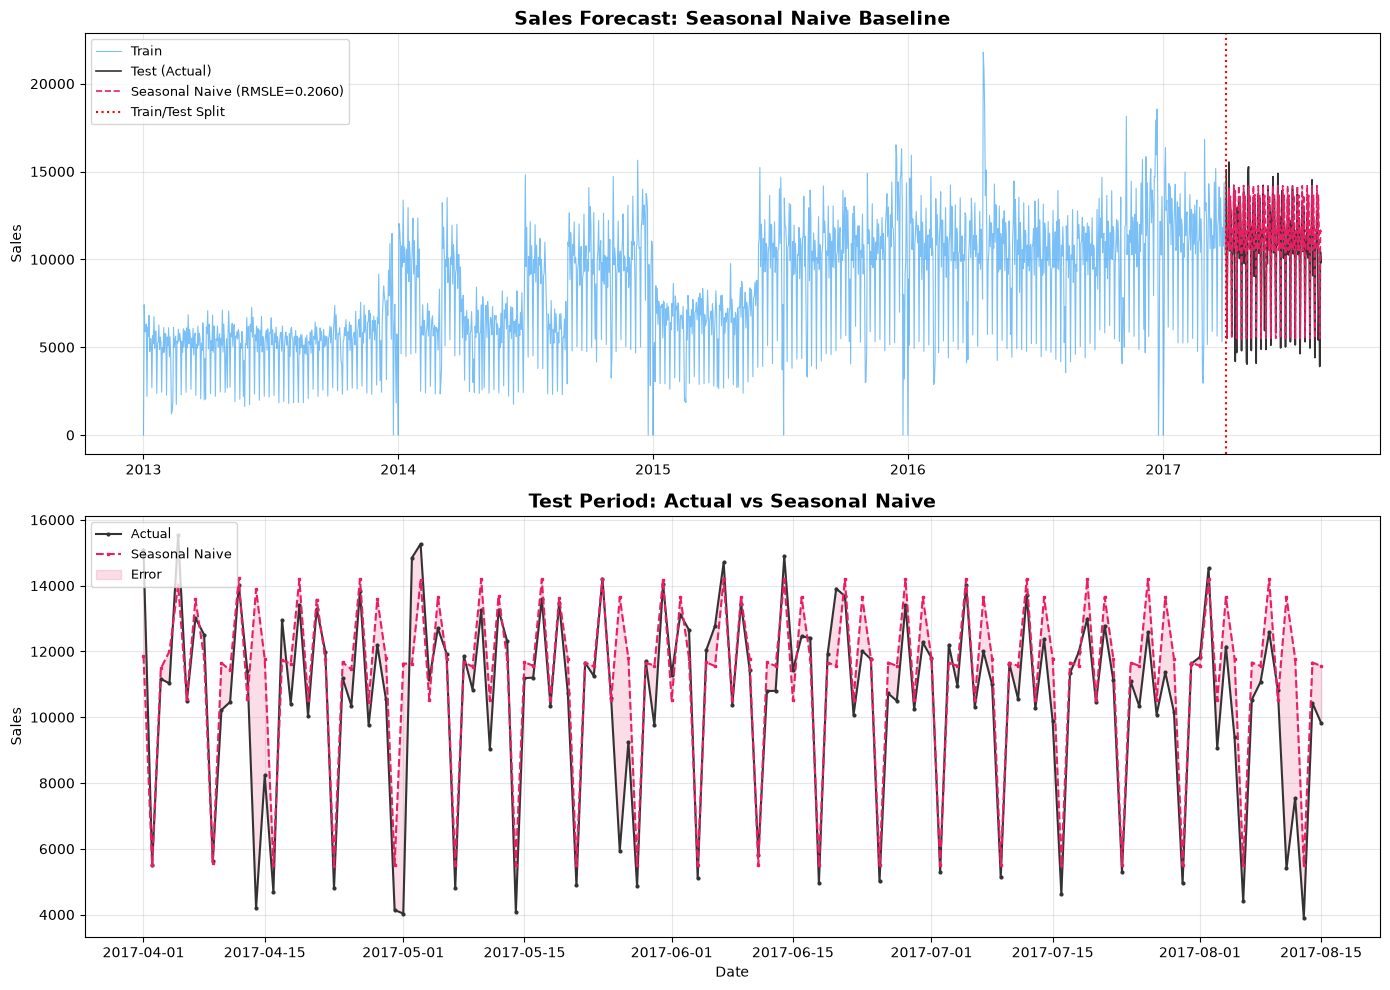

✓ Đã lưu biểu đồ: C:\Users\Asus X515\Downloads\New folder\arima_and_sarima_comparision\results\baseline_forecast.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Plot 1: Train + Test + Prediction ---
ax1 = axes[0]
ax1.plot(train['date'], train['sales'], color='#2196F3', alpha=0.6,
         linewidth=0.8, label='Train')
ax1.plot(test['date'], test['sales'], color='#333333', linewidth=1.2,
         label='Test (Actual)')
ax1.plot(test['date'], baseline_pred, color='#E91E63', linewidth=1.2,
         linestyle='--', label=f'Seasonal Naive (RMSLE={score:.4f})')
ax1.axvline(x=pd.Timestamp('2017-04-01'), color='red', linestyle=':',
            linewidth=1.5, label='Train/Test Split')
ax1.set_title('Sales Forecast: Seasonal Naive Baseline', fontsize=14, fontweight='bold')
ax1.set_ylabel('Sales')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Zoom vào Test period ---
ax2 = axes[1]
ax2.plot(test['date'], test['sales'], color='#333333', linewidth=1.5,
         label='Actual', marker='o', markersize=2)
ax2.plot(test['date'], baseline_pred, color='#E91E63', linewidth=1.5,
         linestyle='--', label='Seasonal Naive', marker='s', markersize=2)
ax2.fill_between(test['date'], test['sales'], baseline_pred,
                 alpha=0.15, color='#E91E63', label='Error')
ax2.set_title('Test Period: Actual vs Seasonal Naive', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Sales')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Lưu biểu đồ
plot_path = os.path.join(PROJECT_ROOT, 'results', 'baseline_forecast.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\u2713 Đã lưu biểu đồ: {plot_path}')

## Kết luận

- **Baseline model**: Seasonal Naive (m=7, avg_weeks=4) — trung bình doanh thu cùng ngày trong tuần của 4 tuần gần nhất.
- **Metric đánh giá**: RMSLE (Root Mean Squared Logarithmic Error).
- Kết quả đã được lưu tại `results/metrics/baseline_rmsle.csv`.
- Mọi model nâng cao (ARIMA, SARIMA, ...) cần đạt RMSLE **thấp hơn** baseline này.